In [1]:
from sktime.datasets import load_tsf_to_dataframe
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
import numpy as np

df, metadata = load_tsf_to_dataframe("./m4_yearly_dataset.tsf")

C:\Users\Альберт\PycharmProjects\hse-project\.venv\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [2]:
pd.set_option('display.max_rows', None)
print(df.head(36))
pd.reset_option('display.max_rows')

                                           series_value
series_name start_timestamp     timestamp              
T1          1979-01-01 12:00:00 0                5172.1
                                1                5133.5
                                2                5186.9
                                3                5084.6
                                4                5182.0
                                5                5414.3
                                6                5576.2
                                7                5752.9
                                8                5955.2
                                9                6087.8
                                10               6238.9
                                11               6317.2
                                12               6262.7
                                13               6361.0
                                14               6427.4
                                15              

In [3]:
df_reset = df.reset_index()
print(df_reset['series_name'].unique())

['T1' 'T2' 'T3' ... 'T22998' 'T22999' 'T23000']


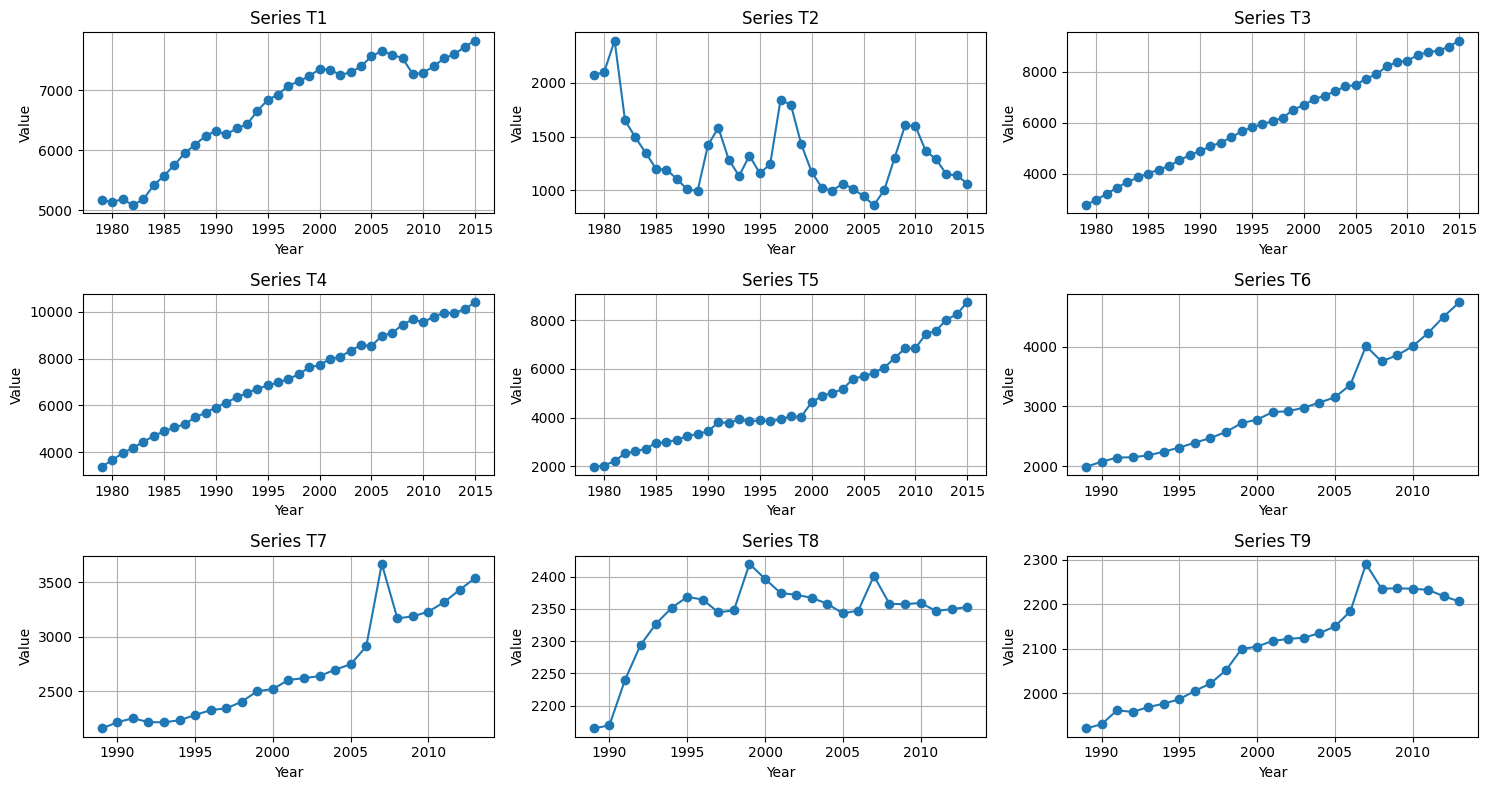

In [4]:
series_names = df_reset['series_name'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, name in enumerate(series_names):
    series_data = df_reset[df_reset['series_name'] == name].copy()
    start_year = pd.to_datetime(series_data['start_timestamp'].iloc[0]).year
    series_data['year'] = start_year + series_data['timestamp']
    
    axes[i].plot(series_data['year'], series_data['series_value'], marker='o', linestyle='-')
    axes[i].set_title(f'Series {name}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Обучаем модель с k=1...
Обучаем модель с k=2...
Обучаем модель с k=3...
Обучаем модель с k=4...
Обучаем модель с k=5...
Обучаем модель с k=6...
Обучаем модель с k=7...
Обучаем модель с k=8...
Обучаем модель с k=9...
Обучаем модель с k=10...


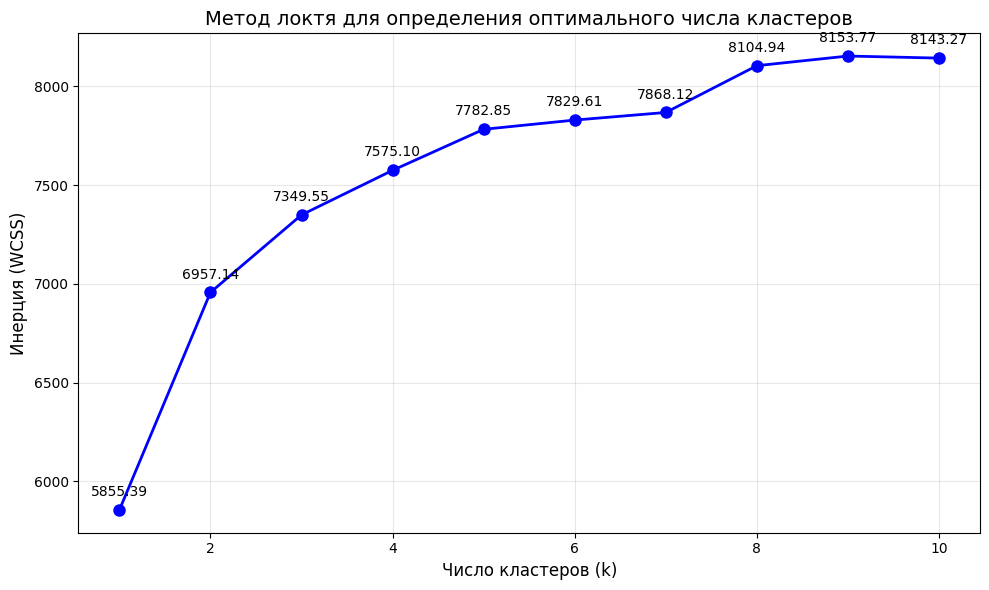


Таблица инерции по числу кластеров:
k	Инерция
1	5855.39
2	6957.14
3	7349.55
4	7575.10
5	7782.85
6	7829.61
7	7868.12
8	8104.94
9	8153.77
10	8143.27


In [5]:
series_150 = df_reset['series_name'].unique()[:150]
series_list = []

for name in series_150:
    series_data = df_reset[df_reset['series_name'] == name].copy()
    values = series_data['series_value'].values
    series_list.append(values)

X = to_time_series_dataset(series_list)
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

k_range = range(1, 11) 
inertias = [] 

for k in k_range:
    print(f"Обучаем модель с k={k}...")
    
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="softdtw",
        max_iter=50,  
        max_iter_barycenter=10,
        random_state=0,
        verbose=0
    ).fit(X_scaled)
    
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Инерция (WCSS)', fontsize=12)
plt.title('Метод локтя для определения оптимального числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)

for i, inertia in enumerate(inertias):
    plt.annotate(f'{inertia:.2f}', (k_range[i], inertia),
               textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

print("\nТаблица инерции по числу кластеров:")
print("k\tИнерция")
for k, inertia in zip(k_range, inertias):
    print(f"{k}\t{inertia:.2f}")


In [7]:
series_150 = df_reset['series_name'].unique()[:150]
series_list = []

for name in series_150:
    series_data = df_reset[df_reset['series_name'] == name].copy()
    values = series_data['series_value'].values
    series_list.append(values)

X = to_time_series_dataset(series_list)

X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

km_dba = TimeSeriesKMeans(
    n_clusters=9,
    metric="softdtw",
    max_iter=5,
    max_iter_barycenter=5,
    random_state=0
).fit(X_scaled)

cluster_labels = km_dba.labels_
print("Метки кластеров:", cluster_labels)

Метки кластеров: [7 1 7 7 4 4 4 0 7 8 7 7 7 7 7 7 7 7 4 4 4 4 6 4 4 4 4 7 8 7 7 7 7 7 7 7 7
 3 4 4 4 4 4 4 7 4 4 0 7 7 7 4 4 4 4 4 4 4 4 7 4 5 4 7 8 7 4 4 7 7 0 4 0 4
 7 7 4 4 4 8 4 4 4 0 5 5 7 3 5 8 7 0 0 8 6 1 1 1 1 8 1 2 8 1 1 3 6 6 2 2 0
 6 6 6 6 0 2 2 2 8 0 2 3 1 6 6 6 2 6 6 0 1 7 4 4 4 4 7 4 4 4 7 4 4 4 7 4 4
 4 7]


C:\Users\Альберт\AppData\Local\Temp\ipykernel_4628\1984403413.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


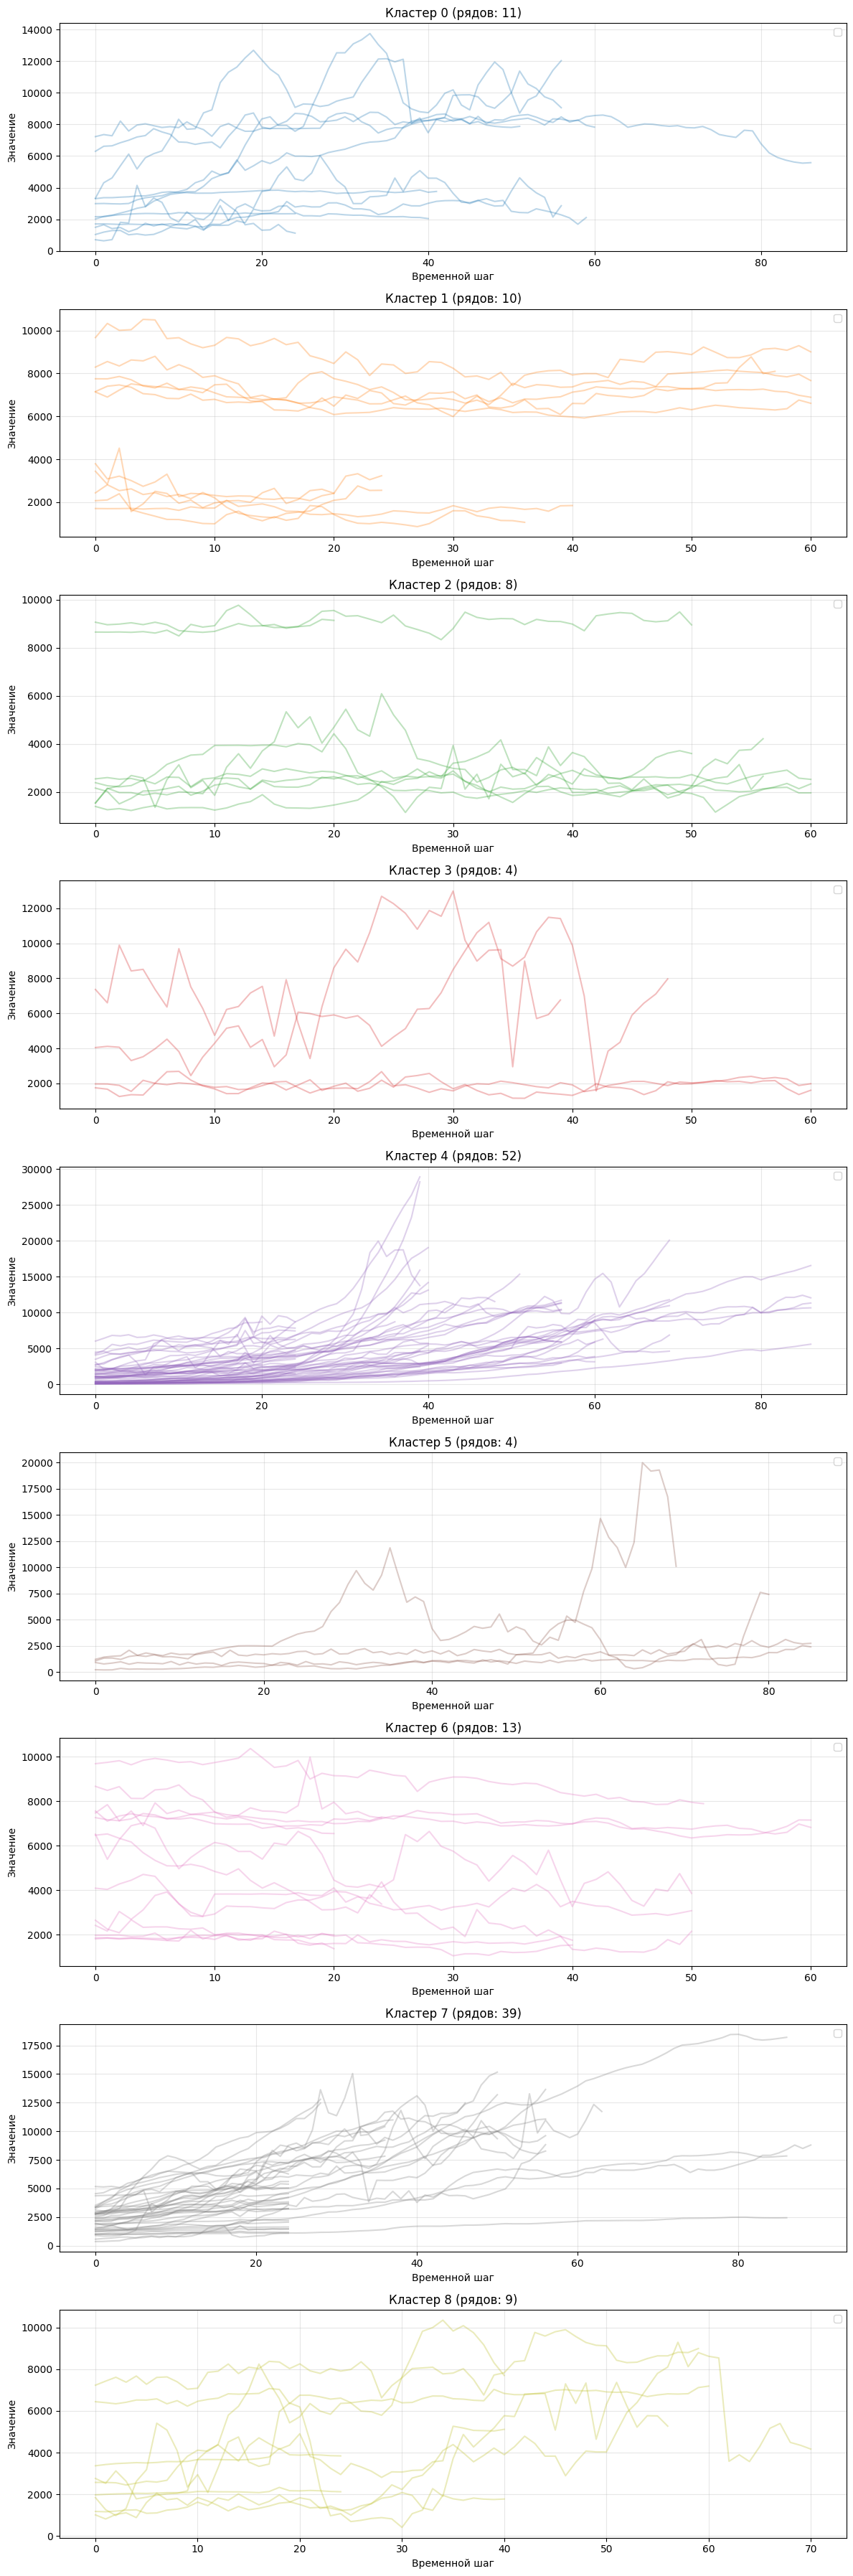

In [8]:
centroids = km_dba.cluster_centers_
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters))
if n_clusters == 1:
    axes = [axes]


for cluster_id in range(n_clusters):
    ax = axes[cluster_id]    
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    for idx in cluster_indices:
        series_name = series_150[idx]
        original_series = df_reset[df_reset['series_name'] == series_name]['series_value'].values
        ax.plot(original_series, alpha=0.3, color=f'C{cluster_id}')
    
    ax.set_title(f'Кластер {cluster_id} (рядов: {len(cluster_indices)})')
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Значение')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

naive_smape_list = []
for values in series_list:
    train = values[:-6]
    test = values[-6:]
    naive_forecast = np.full(6, train[-1])  
    naive_smape_list.append(smape(test, naive_forecast))

unique_clusters = np.unique(cluster_labels)
for cl in unique_clusters:
    indices = np.where(cluster_labels == cl)[0]
    smapes_cluster = [naive_smape_list[i] for i in indices]
    mean_smape = np.mean(smapes_cluster)
    print(f"Кластер {cl}: {len(indices)} рядов, средний Naïve sMAPE = {mean_smape:.2f}")

Кластер 0: 11 рядов, средний Naïve sMAPE = 9.34
Кластер 1: 10 рядов, средний Naïve sMAPE = 12.80
Кластер 2: 8 рядов, средний Naïve sMAPE = 15.57
Кластер 3: 4 рядов, средний Naïve sMAPE = 44.68
Кластер 4: 52 рядов, средний Naïve sMAPE = 16.57
Кластер 5: 4 рядов, средний Naïve sMAPE = 47.97
Кластер 6: 13 рядов, средний Naïve sMAPE = 9.55
Кластер 7: 39 рядов, средний Naïve sMAPE = 9.58
Кластер 8: 9 рядов, средний Naïve sMAPE = 13.17
